In [64]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.11.2 | devices: [CpuDevice(id=0)]


In [65]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02


def target_fn(x):
    """x: (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1)

def make_data(key, n=2048, noise_std=NOISE_STD):
    """Returns X: (n, 1), Y: (n, 1)"""
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,))
    return x[:, None], y[:, None]


X, Y = make_data(jax.random.key(0))

print(f"target variance : {float(Y.var()):.4f}")
print(Y.shape)

target variance : 0.1236
(2048, 1)


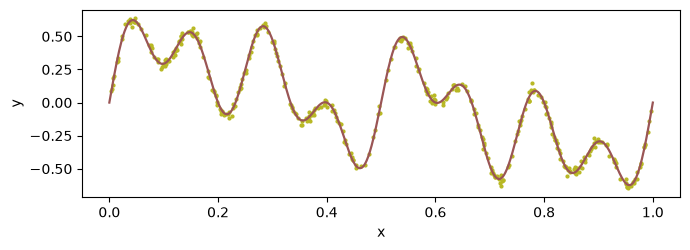

In [66]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b824")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#9a5555", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

# Building the network

I sketched out what an MLP would look like by hand.

### The network worked out by hand for `[1, 2, 2, 1]`

**Layer 1 (input → hidden 1):**
$$
a^1_0 = \sigma\!\left(w^1_{00}\, a^0_0 + b^1_0\right), \qquad
a^1_1 = \sigma\!\left(w^1_{01}\, a^0_0 + b^1_1\right)
$$

**Layer 2 (hidden 1 → hidden 2):**
$$
a^2_0 = \sigma\!\left(w^2_{00}\, a^1_0 + w^2_{10}\, a^1_1 + b^2_0\right), \qquad
a^2_1 = \sigma\!\left(w^2_{01}\, a^1_0 + w^2_{11}\, a^1_1 + b^2_1\right)
$$

**Layer 3 (hidden 2 → output, no nonlinearity):**
$$
a^3_0 = w^3_{00}\, a^2_0 + w^3_{10}\, a^2_1 + b^3
$$

**In matrix form**, with weight $w^l_{ij}$ read as "from source unit $i$ to destination unit $j$":

$$
W^1 = \begin{pmatrix} w^1_{00} \\ w^1_{01} \end{pmatrix}, \quad
W^2 = \begin{pmatrix} w^2_{00} & w^2_{10} \\ w^2_{01} & w^2_{11} \end{pmatrix}, \quad
W^3 = \begin{pmatrix} w^3_{00} & w^3_{10} \end{pmatrix}
$$

so that each layer is just

$$
a^l = \sigma\!\left(W^l a^{l-1} + b^l\right)
$$

with $W^l$ shaped $(n_l, n_{l-1})$ — rows are destination units, columns are source units — and $\sigma$ applied elementwise (identity on the output layer).

$$
\Theta = \left(\,[W^1, b^1],\ [W^2, b^2],\ [W^3, b^3]\,\right)
$$

In [67]:
def init_mlp(key, layer_sizes):
    keys = jax.random.split(key,len(layer_sizes) - 1) # one subkey per layer
    m1 = layer_sizes[1]
    m2 = layer_sizes[2]

    # initialize biases as zeros
    b1 = jnp.zeros(m1)
    b2 = jnp.zeros(m2)
    b3 = jnp.zeros(1)

    # initialize weights randomly
    # std normalization for weights keeps variance low -> called He initialization
    std1 = jnp.sqrt(2 / 1)
    w1 = jax.random.normal(keys[0],(m1, 1)) * std1
    std2 = jnp.sqrt(2 / m1)
    w2 = jax.random.normal(keys[1],(m2, m1)) * std2
    std3 = jnp.sqrt(2 / m2)
    w3 = jax.random.normal(keys[2],(1, m2)) * std3

    theta1 = [w1,b1]
    theta2 = [w2,b2]
    theta3 = [w3,b3]
    params = [theta1,theta2,theta3]
    return params

def relu(z):
    a = jnp.clip(z,0,None) #turns neg values to 0
    return a

def forward(params, x):
    """Runs the MLP forward for an input x = (1,)"""
    #first hidden layer
    w1 = params[0][0]
    b1 = params[0][1]
    # assume for now x is a single number
    z1 = w1 @ x + b1
    a1 = relu(z1)

    #second hidden layer
    w2 = params[1][0]
    b2 = params[1][1]
    z2 = w2 @ a1 + b2
    a2 = relu(z2)

    #output layer
    w3 = params[2][0]
    b3 = params[2][1]
    z3 = w3 @ a2 + b3
    return z3

def forward_batch(params,X):
    """Run forward on a batch of input data size X=(N,1)"""
    #don't map over arg 0 (params), map axis 0 of arg 1 (X)
    batched_forward = jax.vmap(forward,in_axes= (None,0)) 
    # returns shape (N, 1)
    return batched_forward(params,X)
    # or:
    # Z3 = [forward(params,X[0][i]) for i in range(N)]
    # or even safer way:
    # z3 = jnp.zeros(N)
    # for i in range(N): z3[i] = forward(params,X[0][i])

def loss_fn(params, X, Y):
    # 
    return jnp.mean((forward_batch(params,X) - Y)**2)

In [68]:
# hyperparams
n_epochs = 400
epochs = np.arange(stop=400)
batch_size = 128
eta_default = 0.1 # learning rate
n_train = X.shape[0]

def init_singlevar(params):
    updated_var = jax.tree_util.tree_map(jnp.zeros_like, params)
    return updated_var

def init_adam(params):
    v = jax.tree_util.tree_map(jnp.zeros_like, params)
    m = jax.tree_util.tree_map(jnp.zeros_like, params)
    t = 0 # time counter
    return (v, m, t)


def gradient_descent(params, grads,useless_var,eta):
    """Does simplest gradient descent. useless_variable is passed so train() can run
    for all optimizers"""

    params_updated = []
    for j in range(len(params)):
        W, b = params[j]
        dW, db = grads[j]
        params_updated.append([W - eta * dW, b - eta * db])
    return params_updated, useless_var

def gradient_descent_momentum(params,grads,v,eta,beta=0.9):
    params_updated, v_updated = [], []
    #v = jax.tree_util.tree_map(jnp.zeros_like, params)

    for j in range(len(params)):
        W, b = params[j]
        dW, db = grads[j]
        vW, vb = v[j]

        # v is running exponential moving average of past gradients
        # "velocity" remembers recent direction
        vW_new, vb_new = beta * vW + dW, beta * vb + db

        params_updated.append([W - eta * vW_new, b - eta * vb_new])
        v_updated.append([vW_new, vb_new])
    return params_updated, v_updated

def adagrad(params,grads,G, eta, epsilon = 1e-8):
    params_updated, G_updated= [], []
    
    for j in range(len(params)):
        W, b = params[j]
        dW, db = grads[j]
        GW, Gb = G[j]
        # G accumulated sum of squared gradients per parameter

        GW_new, Gb_new = GW + dW**2, Gb + db**2

        params_updated.append([W - eta * dW / (jnp.sqrt(GW_new) + epsilon), b - eta * db / (jnp.sqrt(Gb_new) + epsilon)])
        G_updated.append([GW_new,Gb_new])
    return params_updated, G_updated

def adam(params,grads,state,eta,beta1=0.9,beta2=0.999, epsilon = 1e-8):
    # unpack the update variables initialized for adam
    m, v, t = state
    params_updated, v_updated, m_updated = [], [], []
    t += 1
    for j in range(len(params)):
        W, b = params[j]
        dW, db = grads[j]
        vW, vb = v[j]
        mW, mb = m[j]

        mW_new, mb_new = beta1*mW + (1 - beta1)*dW,    beta1*mb + (1 - beta1)*db
        vW_new, vb_new = beta2*vW + (1 - beta2)*dW**2, beta2*vb + (1 - beta2)*db**2

        mW_hat, mb_hat = mW_new / (1 - beta1**t), mb_new / (1 - beta1**t)
        vW_hat, vb_hat = vW_new / (1 - beta2**t), vb_new / (1 - beta2**t)

        params_updated.append([W - eta * mW_hat / (jnp.sqrt(vW_hat) + epsilon), 
                               b - eta * mb_hat / (jnp.sqrt(vb_hat) + epsilon)])
        m_updated.append([mW_new, mb_new])
        v_updated.append([vW_new, vb_new])

    updated_state = (m_updated, v_updated, t)
    return params_updated, updated_state


def train(params, X, Y, update_fxn, init_fxn,key, batch = True, epochs = epochs, batch_size = batch_size, eta = eta_default):
    losses = []
    updated_var = init_fxn(params)

    for epoch in epochs:
        # for plain gradient descent, no batching
        if batch == False:
            losses.append(loss_fn(params,X,Y)) # calculate loss
            grads = jax.grad(loss_fn)(params, X, Y) # backprop
            useless_var = None
            params, useless_var = update_fxn(params,grads,useless_var,eta)
        else:
            # for batching (SGD and beyond): randomly shuffle the data each epoch
            key, subkey = jax.random.split(key)
            perm = jax.random.permutation(subkey, n_train)
            X_shuffled, Y_shuffled = X[perm], Y[perm]

            sublosses = []
            # loop over batches (n_train / batch_size, 2048/16 = 128 times)
            for i in range(0,n_train,batch_size):
                x_batch = X_shuffled[i:i+batch_size]
                y_batch = Y_shuffled[i:i+batch_size]
                sublosses.append(loss_fn(params,x_batch,y_batch))

                grads = jax.grad(loss_fn)(params,x_batch,y_batch)
                params, updated_var = update_fxn(params,grads,updated_var,eta)

            losses.append(jnp.mean(jnp.array(sublosses)))

    return params, losses



In [69]:
# execute for different training models

# initiate MLP
params = init_mlp(jax.random.key(0),[1,128,128,1])

params_GD, losses_GD = train(params, X, Y, gradient_descent,init_singlevar,batch=False,key=jax.random.key(0))


In [ ]:
# SGD
params = init_mlp(jax.random.key(0),[1,128,128,1])
params_SGD, losses_SGD = train(params, X, Y, gradient_descent,init_singlevar,batch=True,key=jax.random.key(0))

In [ ]:
# SGD w momentum: 
params = init_mlp(jax.random.key(0),[1,128,128,1])
params_SGD_mom, losses_SGD_mom = train(params, X, Y, gradient_descent_momentum,init_singlevar,batch=True,key=jax.random.key(0),eta=0.01)

In [ ]:
# Adagrad
params = init_mlp(jax.random.key(0),[1,128,128,1])
params_adagrad, losses_adagrad = train(params, X, Y, adagrad, init_singlevar,batch=True,key=jax.random.key(0),eta=0.5)

In [ ]:
# adam
params = init_mlp(jax.random.key(0),[1,128,128,1])
arams_adam, losses_adam = train(params, X, Y, adam, init_adam,batch=True,key=jax.random.key(0),eta=0.1)

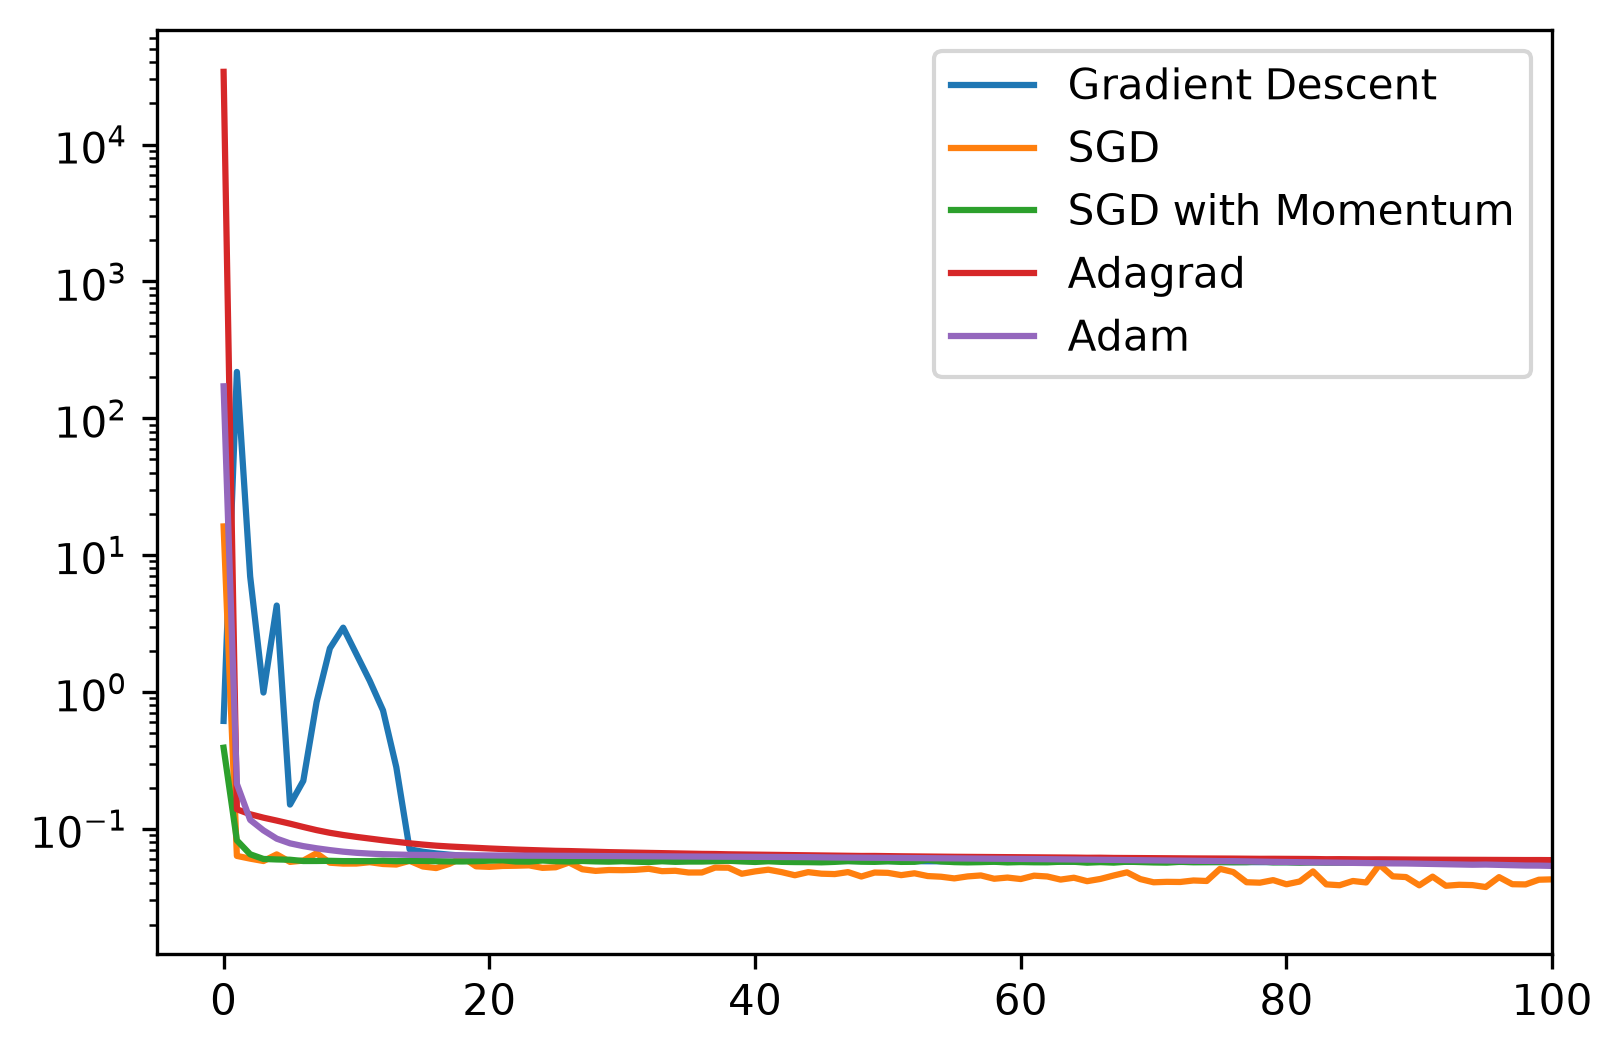

In [ ]:
plt.figure(figsize=(6,4),dpi=300)
plt.plot(epochs,losses_GD,label='Gradient Descent')
plt.plot(epochs,losses_SGD,label="SGD")
plt.plot(epochs,losses_SGD_mom,label="SGD with Momentum")
plt.plot(epochs,losses_adagrad,label="Adagrad")
plt.plot(epochs,losses_adam,label='Adam')
plt.legend()
plt.xlim(-5,100)

plt.yscale('log')

In [ ]:
print("GD:")
print(jnp.stack(losses_GD[:100]).round(2))
print("SGD:")
print(jnp.stack(losses_SGD[:100]).round(2))
print("SGD_mom:")
print(jnp.stack(losses_SGD_mom[:10]).round(2))
print("adagrad:")
print(jnp.stack(losses_adagrad[:10]).round(2))
print("adam:")
print(jnp.stack(losses_adam[:10]).round(2))

GD:
[6.1000001e-01 2.1814999e+02 6.9800000e+00 9.8999995e-01 4.2799997e+00
 1.4999999e-01 2.2000000e-01 8.3999997e-01 2.0799999e+00 2.9500000e+00
 1.8900000e+00 1.2099999e+00 7.2999996e-01 2.8000000e-01 7.0000000e-02
 7.0000000e-02 7.0000000e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02 5.9999999e-02
 5

In [ ]:
print(losses_GD[:2])

[Array(0.614524, dtype=float32), Array(218.14922, dtype=float32)]
